# Step 1: Dataset Load and Environment Setup

In [1]:
import pandas as pd
from google.colab import drive
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Mount Drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/SHIELD_Project/data'

# depends on which split we are doing if its 80:20 then its 8020, if 70:30, then 7030
split_name = '8020'

# Load the processed datasets
X_train = pd.read_csv(f'{drive_path}/X_train_processed_{split_name}.csv')
y_train = pd.read_csv(f'{drive_path}/y_train_processed_{split_name}.csv').values.ravel()
X_test = pd.read_csv(f'{drive_path}/X_test_processed_{split_name}.csv')
y_test = pd.read_csv(f'{drive_path}/y_test_processed_{split_name}.csv').values.ravel()

print(f"Data loaded successfully!")
print(f"Training Features: {X_train.shape}")
print(f"Testing Features: {X_test.shape}")

Mounted at /content/drive
Data loaded successfully!
Training Features: (10558, 20)
Testing Features: (1364, 20)


# Step 2: Random Forest Model Training 80:20 + CV = 5

In [2]:
print("Starting Random Forest CV...")

# Define the model and the parameter grid to test
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Run 5-fold Cross Validation
rf_grid = GridSearchCV(estimator=rf, param_grid=rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

# Save the best model
best_rf = rf_grid.best_estimator_
print(f"Best RF Parameters: {rf_grid.best_params_}")

Starting Random Forest CV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best RF Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


# Step 3: Extreme Gradient Boosting (XGBoost) Model Training 8020 + CV = 5

In [3]:
print("Starting XGBoost CV...")

# Define the model and the parameter grid
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Run 5-fold Cross Validation
xgb_grid = GridSearchCV(estimator=xgb, param_grid=xgb_params, cv=5, scoring='f1', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

# Save the best model
best_xgb = xgb_grid.best_estimator_
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")

Starting XGBoost CV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [15:26:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Parameters: {'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 200}


# Step 4: Model Evaluation & Comparative Analysis

Reports will be saved to: /content/drive/MyDrive/SHIELD_Project/reports



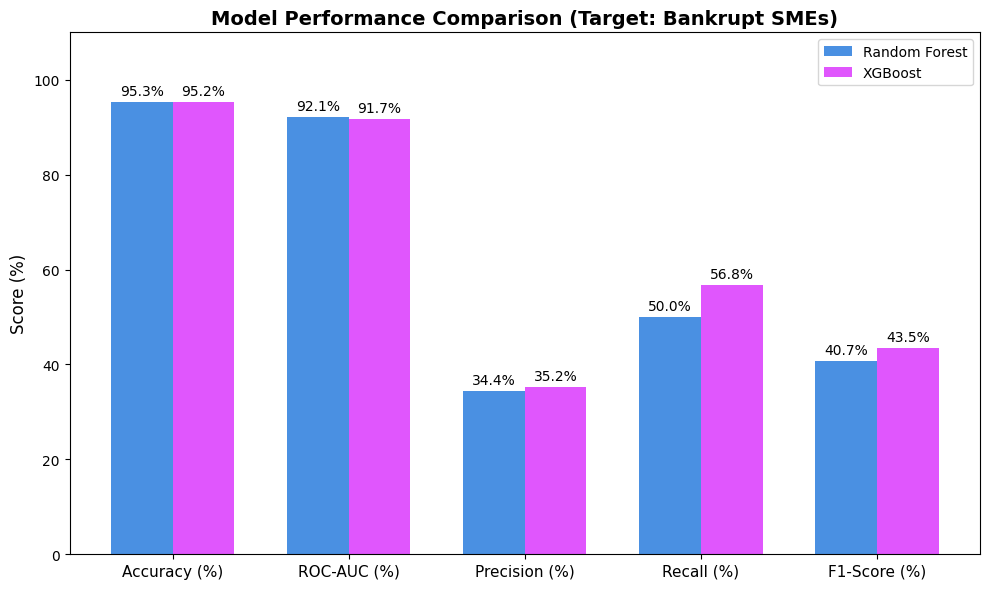

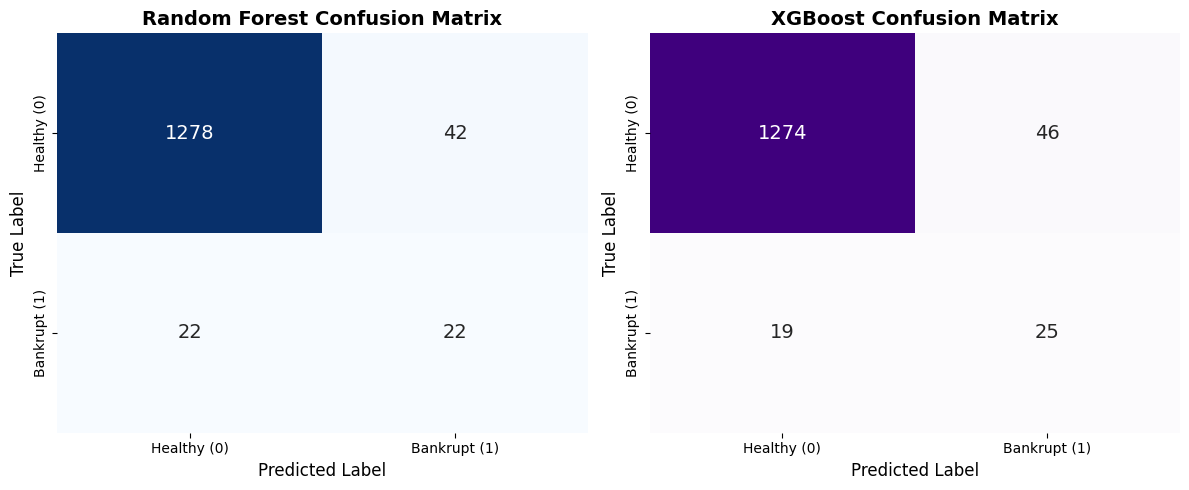

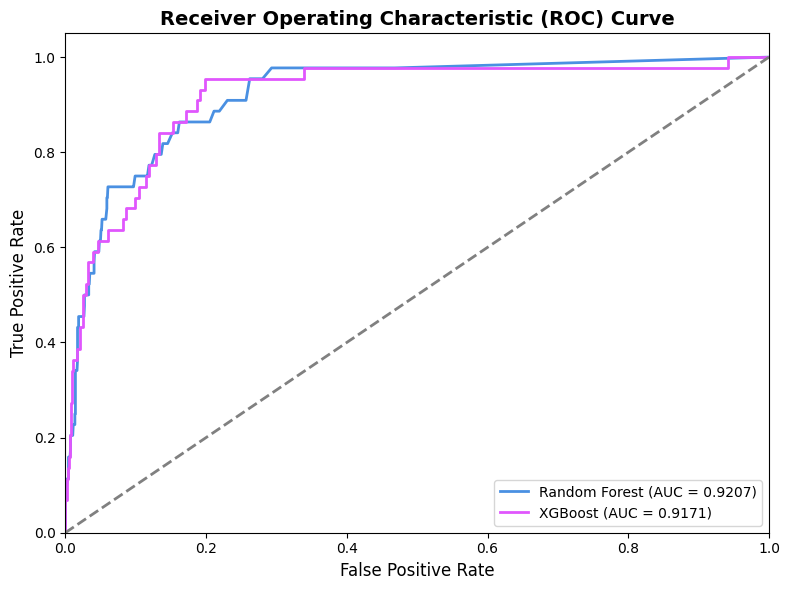


All comparative visualizations have been successfully generated and saved to your Drive!


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

# 1. Setup Reports Directory
report_dir = '/content/drive/MyDrive/SHIELD_Project/reports'
os.makedirs(report_dir, exist_ok=True)
print(f"Reports will be saved to: {report_dir}\n")

# 2. Generate Predictions
models = {'Random Forest': best_rf, 'XGBoost': best_xgb}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics for the Minority Class (1 = Bankrupt)
    results[name] = {
        'Accuracy (%)': accuracy_score(y_test, y_pred) * 100,
        'Precision (%)': precision_score(y_test, y_pred) * 100,
        'Recall (%)': recall_score(y_test, y_pred) * 100,
        'F1-Score (%)': f1_score(y_test, y_pred) * 100,
        'ROC-AUC (%)': roc_auc_score(y_test, y_prob) * 100,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

# ==========================================
# VISUALIZATION 1: Performance Metrics Comparison
# ==========================================
metrics_list = ['Accuracy (%)', 'ROC-AUC (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
rf_scores = [results['Random Forest'][m] for m in metrics_list]
xgb_scores = [results['XGBoost'][m] for m in metrics_list]

x = np.arange(len(metrics_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='#4a90e2')
rects2 = ax.bar(x + width/2, xgb_scores, width, label='XGBoost', color='#e056fd')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison (Target: Bankrupt SMEs)', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.legend()
ax.set_ylim(0, 110)

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.savefig(f'{report_dir}/model_comparison_bar.png', dpi=300)
plt.show()

# ==========================================
# VISUALIZATION 2: Confusion Matrices
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if name == 'Random Forest' else 'Purples',
                ax=axes[idx], cbar=False, annot_kws={"size": 14})
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=14, weight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].set_ylabel('True Label', fontsize=12)
    axes[idx].xaxis.set_ticklabels(['Healthy (0)', 'Bankrupt (1)'])
    axes[idx].yaxis.set_ticklabels(['Healthy (0)', 'Bankrupt (1)'])

plt.tight_layout()
plt.savefig(f'{report_dir}/confusion_matrices.png', dpi=300)
plt.show()

# ==========================================
# VISUALIZATION 3: ROC Curves
# ==========================================
plt.figure(figsize=(8, 6))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    roc_auc = results[name]['ROC-AUC (%)'] / 100
    color = '#4a90e2' if name == 'Random Forest' else '#e056fd'
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, weight='bold')
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f'{report_dir}/roc_curves.png', dpi=300)
plt.show()

print("\nAll comparative visualizations have been successfully generated and saved to your Drive!")

# Step 5: Model Extraction

In [6]:
import joblib
import os

# 1. Setup Models Directory
model_dir = '/content/drive/MyDrive/SHIELD_Project/models'
os.makedirs(model_dir, exist_ok=True)

# 2. Export the tuned XGBoost model
model_path = f'{model_dir}/xgb_shield_model.joblib'
joblib.dump(best_xgb, model_path)

print(f"Success! XGBoost model saved to: {model_path}")
print("Ready for deployment.")

Success! XGBoost model saved to: /content/drive/MyDrive/SHIELD_Project/models/xgb_shield_model.joblib
Ready for deployment.
